In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc dữ liệu
df = pd.read_csv('Jobs_IT.csv')

# Chuyển đổi salary_min và salary_max sang số
df['salary_min'] = pd.to_numeric(df['salary_min'], errors='coerce')
df['salary_max'] = pd.to_numeric(df['salary_max'], errors='coerce')

# Chuyển đổi posted_date sang định dạng datetime (nếu bạn cần sử dụng sau)
df['posted_date'] = pd.to_datetime(df['posted_date'], errors='coerce', dayfirst=True)

# Xử lý địa điểm: gộp 'TP. Hồ Chí Minh' và 'Hồ Chí Minh' lại
df['location_city'] = df['location_city'].replace({
    'TP. Hồ Chí Minh': 'Hồ Chí Minh',
    'TP. HCM': 'Hồ Chí Minh',
})


C:\Users\DELL\AppData\Local\Temp\ipykernel_13712\1434166094.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=field_counts.index, y=field_counts.values, palette='viridis')


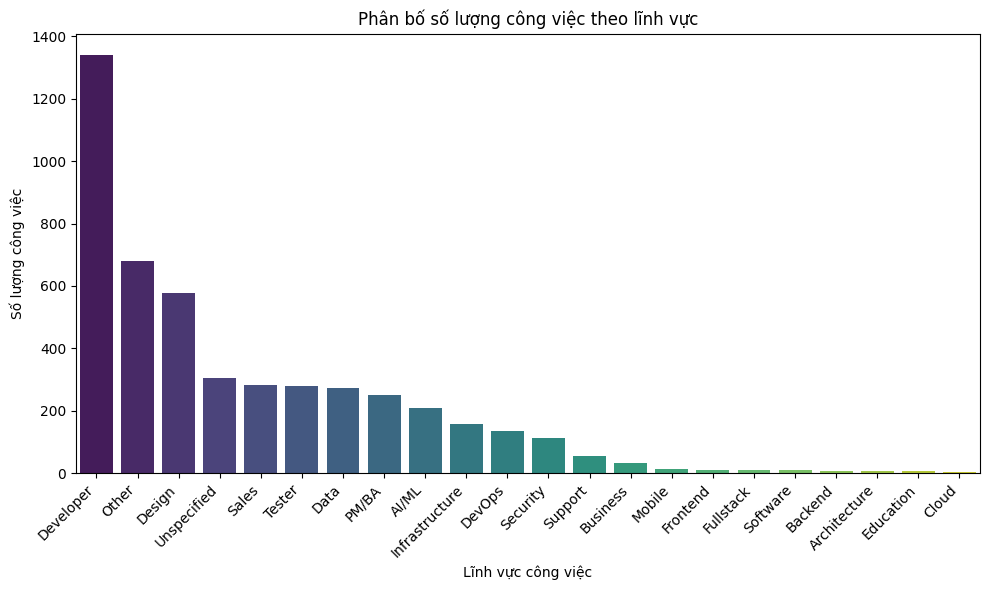

In [4]:
# 1. Biểu đồ phân bố công việc theo lĩnh vực (job_field)
plt.figure(figsize=(10,6))
field_counts = df['job_field'].value_counts()
sns.barplot(x=field_counts.index, y=field_counts.values, palette='viridis')
plt.title('Phân bố số lượng công việc theo lĩnh vực')
plt.xlabel('Lĩnh vực công việc')
plt.ylabel('Số lượng công việc')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


C:\Users\DELL\AppData\Local\Temp\ipykernel_13712\3241411967.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=level_counts.index, y=level_counts.values, palette='crest')


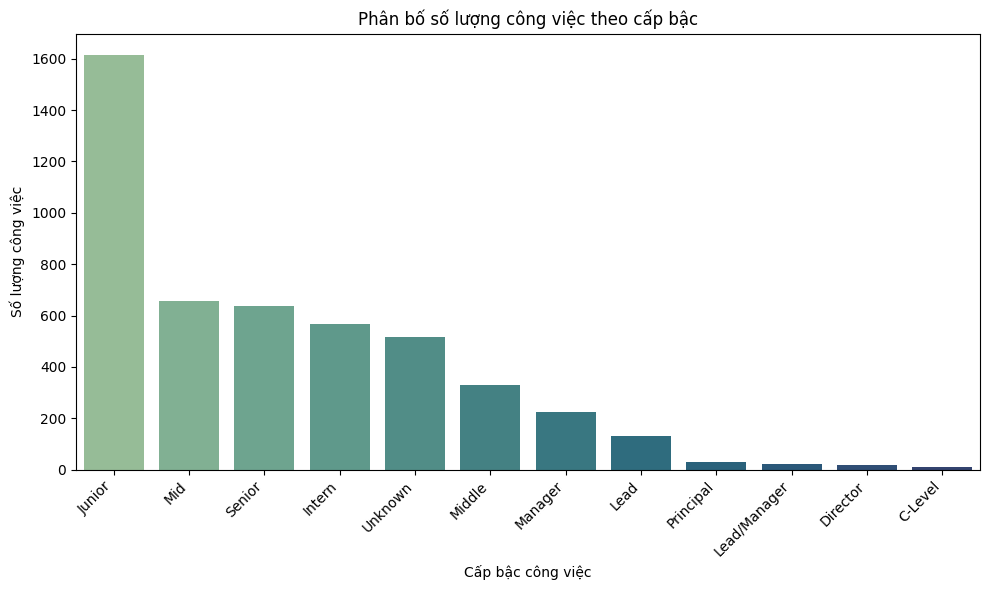

In [5]:
# 2. Biểu đồ phân bố công việc theo cấp bậc (job_level)
plt.figure(figsize=(10,6))
level_counts = df['job_level'].value_counts()
sns.barplot(x=level_counts.index, y=level_counts.values, palette='crest')
plt.title('Phân bố số lượng công việc theo cấp bậc')
plt.xlabel('Cấp bậc công việc')
plt.ylabel('Số lượng công việc')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_13712\1440560970.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_counts.index, y=city_counts.values, palette='mako')


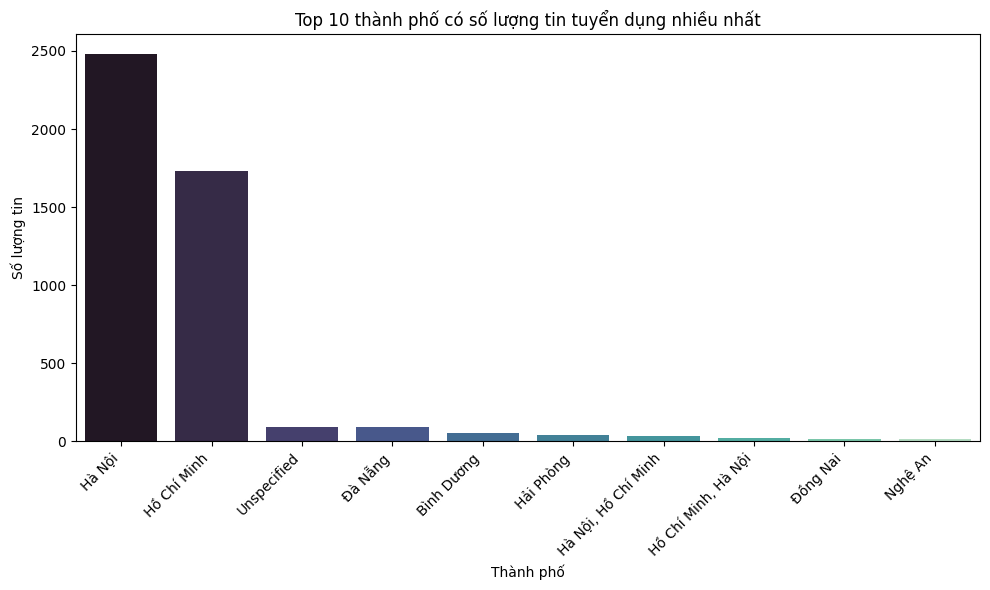

In [6]:
# 3. Biểu đồ Top 10 thành phố đăng tuyển nhiều nhất
plt.figure(figsize=(10,6))
city_counts = df['location_city'].value_counts().head(10)
sns.barplot(x=city_counts.index, y=city_counts.values, palette='mako')
plt.title('Top 10 thành phố có số lượng tin tuyển dụng nhiều nhất')
plt.xlabel('Thành phố')
plt.ylabel('Số lượng tin')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


C:\Users\DELL\AppData\Local\Temp\ipykernel_13712\3014149888.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=median_salary.index, y=median_salary['salary_min'], palette='flare')


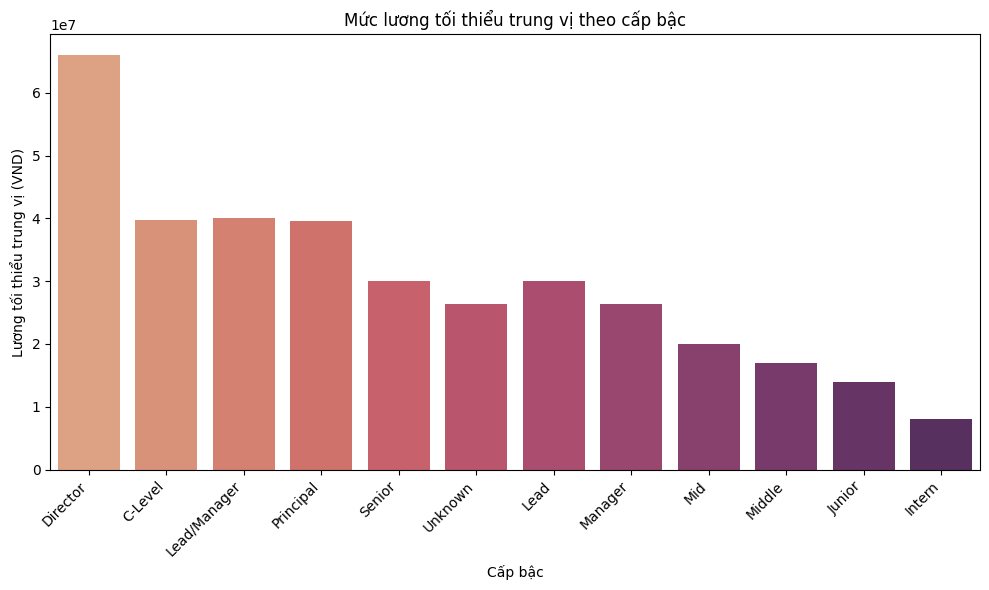

C:\Users\DELL\AppData\Local\Temp\ipykernel_13712\3014149888.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=median_salary.index, y=median_salary['salary_max'], palette='rocket')


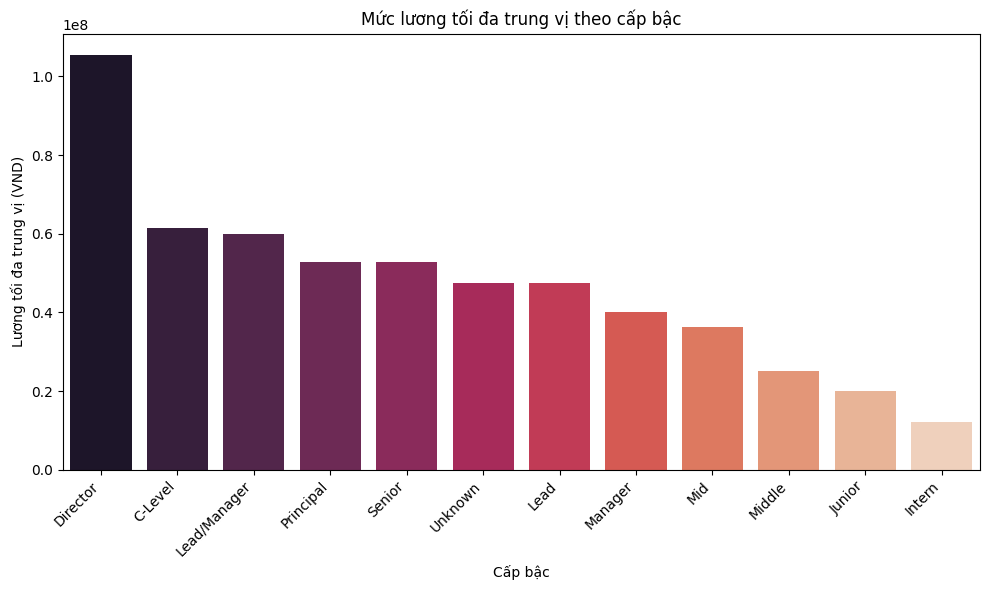

In [7]:
# 4. Biểu đồ mức lương trung vị theo cấp bậc (lọc bỏ lương 0)
df_salary = df[(df['salary_min'] > 0) & (df['salary_max'] > 0)]
median_salary = df_salary.groupby('job_level')[['salary_min','salary_max']].median().sort_values('salary_max', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=median_salary.index, y=median_salary['salary_min'], palette='flare')
plt.title('Mức lương tối thiểu trung vị theo cấp bậc')
plt.xlabel('Cấp bậc')
plt.ylabel('Lương tối thiểu trung vị (VND)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(x=median_salary.index, y=median_salary['salary_max'], palette='rocket')
plt.title('Mức lương tối đa trung vị theo cấp bậc')
plt.xlabel('Cấp bậc')
plt.ylabel('Lương tối đa trung vị (VND)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_13712\1694054098.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_skills, x='count', y='skill', palette='rainbow')


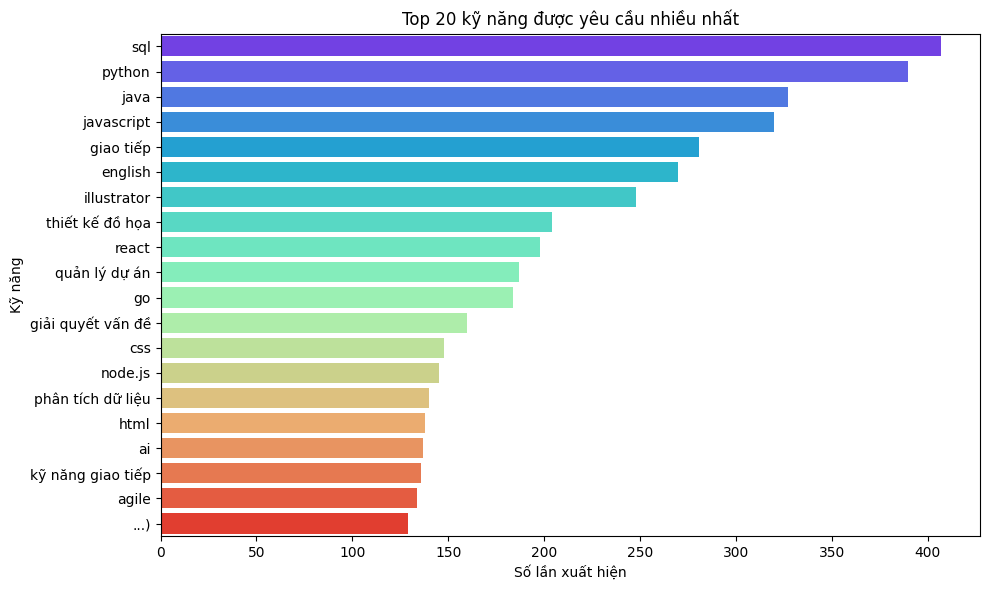

In [ ]:
# 5. Biểu đồ Top 20 kỹ năng được yêu cầu nhiều nhất
from collections import Counter
import re
# Chuẩn hóa và tách kỹ năng
skills_counter = Counter()
for skills in df['skills'].dropna().astype(str):
    # Xóa dấu ngoặc và dấu nháy
    cleaned = re.sub(r'[\[\]"\']', '', skills)
    for skill in cleaned.split(','):
        skill = skill.strip().lower()
        if skill and skill != '...':
            skills_counter[skill] += 1
top_skills = pd.DataFrame(skills_counter.most_common(20), columns=['skill', 'count'])

plt.figure(figsize=(10,6))
sns.barplot(data=top_skills, x='count', y='skill', palette='rainbow')
plt.title('Top 20 kỹ năng được yêu cầu nhiều nhất')
plt.xlabel('Số lần xuất hiện')
plt.ylabel('Kỹ năng')
plt.tight_layout()
plt.show()

In [14]:
# 8. Biểu đồ tròn phân bố số lượng tin tuyển dụng theo nguồn

# Đếm số lượng tin theo nguồn
source_counts = df['source'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(source_counts.values,labels=source_counts.index,outopct='%1.1f%%',tartangle=140,colors=plt.cm.Set3.colors)

plt.title('Phân bố số lượng tin tuyển dụng theo nguồn')
plt.axis('equal')  # Đảm bảo biểu đồ tròn
plt.tight_layout()
plt.show()


TypeError: pie() got an unexpected keyword argument 'outopct'

<Figure size 800x800 with 0 Axes>

In [1]:
import pandas as pd
import numpy as np

# Đọc dữ liệu
df = pd.read_csv('Jobs_IT.csv')

# Chuyển salary_min và salary_max sang số
df['salary_min'] = pd.to_numeric(df['salary_min'], errors='coerce')
df['salary_max'] = pd.to_numeric(df['salary_max'], errors='coerce')

# Tạo cột avg_salary: trung bình của salary_min và salary_max nếu cả hai > 0
mask = (df['salary_min'] > 0) & (df['salary_max'] > 0)
df['avg_salary'] = np.where(mask, (df['salary_min'] + df['salary_max']) / 2, np.nan)

# Tỷ lệ tin đăng có lương thỏa thuận (salary_negotiable)
negotiable_counts = df['salary_negotiable'].value_counts(normalize=True) * 100
print("Tỷ lệ tin đăng có lương thỏa thuận (1 = Thỏa thuận, 0 = Có lương cụ thể):")
print(negotiable_counts)

# Lương trung vị trung bình cho toàn bộ dữ liệu
overall_median_avg_salary = df['avg_salary'].median()
print(f"\nMức lương trung vị của avg_salary toàn bộ dữ liệu: {overall_median_avg_salary:,.0f} VND")

# Thống kê lương theo cấp bậc (job_level)
median_by_level = (df.groupby('job_level')['avg_salary']
                     .median()
                     .dropna()
                     .sort_values(ascending=False))
print("\nMức lương trung vị avg_salary theo cấp bậc:")
print(median_by_level)

# Thống kê lương theo lĩnh vực (job_field)
median_by_field = (df.groupby('job_field')['avg_salary']
                     .median()
                     .dropna()
                     .sort_values(ascending=False))
print("\nMức lương trung vị avg_salary theo lĩnh vực:")
print(median_by_field)

# Thống kê lương theo địa điểm: chọn top 10 thành phố có lương trung vị cao nhất
median_by_city = (df.groupby('location_city')['avg_salary']
                    .median()
                    .dropna()
                    .sort_values(ascending=False)
                    .head(10))
print("\nTop 10 thành phố có mức lương trung vị avg_salary cao nhất:")
print(median_by_city)

# Nếu muốn xuất DataFrame kết quả ra file CSV để tiện xem, có thể dùng:
# median_by_level.to_csv('median_salary_by_level.csv')
# median_by_field.to_csv('median_salary_by_field.csv')
# median_by_city.to_csv('top10_median_salary_by_city.csv')


Tỷ lệ tin đăng có lương thỏa thuận (1 = Thỏa thuận, 0 = Có lương cụ thể):
salary_negotiable
1.0    51.388305
0.0    48.611695
Name: proportion, dtype: float64

Mức lương trung vị của avg_salary toàn bộ dữ liệu: 20,000,000 VND

Mức lương trung vị avg_salary theo cấp bậc:
job_level
Director        8.576750e+07
C-Level         5.059125e+07
Lead/Manager    5.000000e+07
Principal       4.618250e+07
Lead            4.125000e+07
Senior          4.000000e+07
Manager         3.900000e+07
Unknown         3.694600e+07
Mid             2.916667e+07
Middle          2.250000e+07
Junior          1.750000e+07
Intern          1.000000e+07
Name: avg_salary, dtype: float64

Mức lương trung vị avg_salary theo lĩnh vực:
job_field
AI/ML             3.958500e+07
Mobile            3.000000e+07
Software          2.975000e+07
DevOps            2.958333e+07
Developer         2.900000e+07
PM/BA             2.850000e+07
Backend           2.767500e+07
Infrastructure    2.550000e+07
Fullstack         2.500000e+07
Uns

C:\Users\DELL\AppData\Local\Temp\ipykernel_29048\1801208222.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_salary_valid, x='job_level', y='avg_salary', palette='coolwarm')


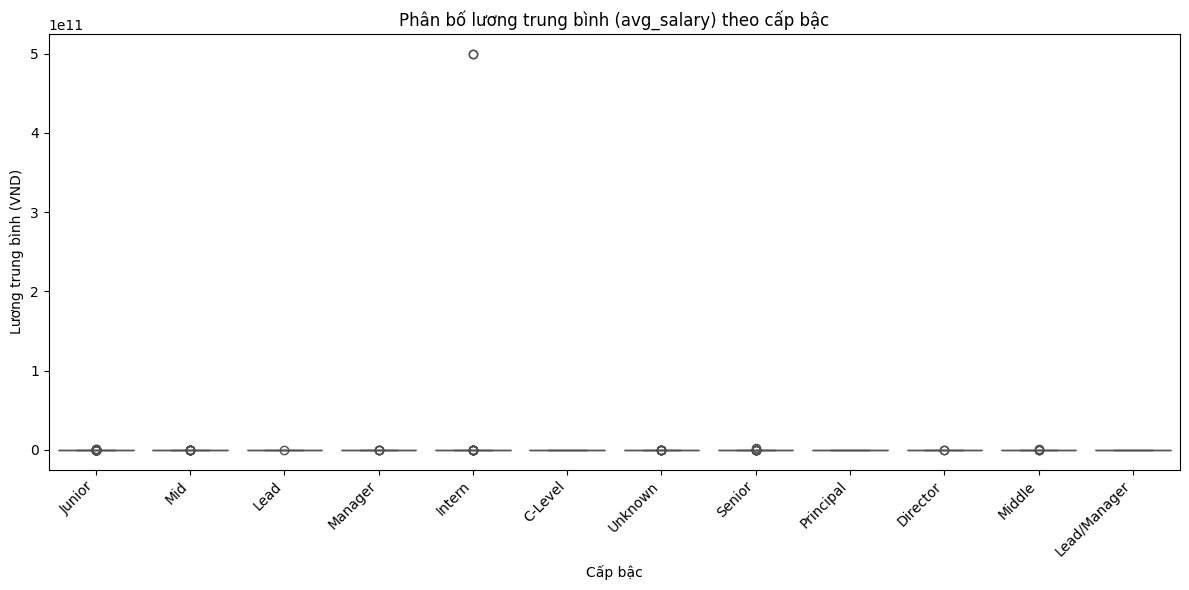

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lọc dữ liệu có avg_salary hợp lệ (khác NaN)
df_salary_valid = df[df['avg_salary'].notna()]

# 1. Biểu đồ boxplot lương trung bình theo cấp bậc
plt.figure(figsize=(12,6))
sns.boxplot(data=df_salary_valid, x='job_level', y='avg_salary', palette='coolwarm')
plt.title('Phân bố lương trung bình (avg_salary) theo cấp bậc')
plt.xlabel('Cấp bậc')
plt.ylabel('Lương trung bình (VND)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_29048\1820086092.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_fields_salary, x='job_field', y='avg_salary', palette='Set2')


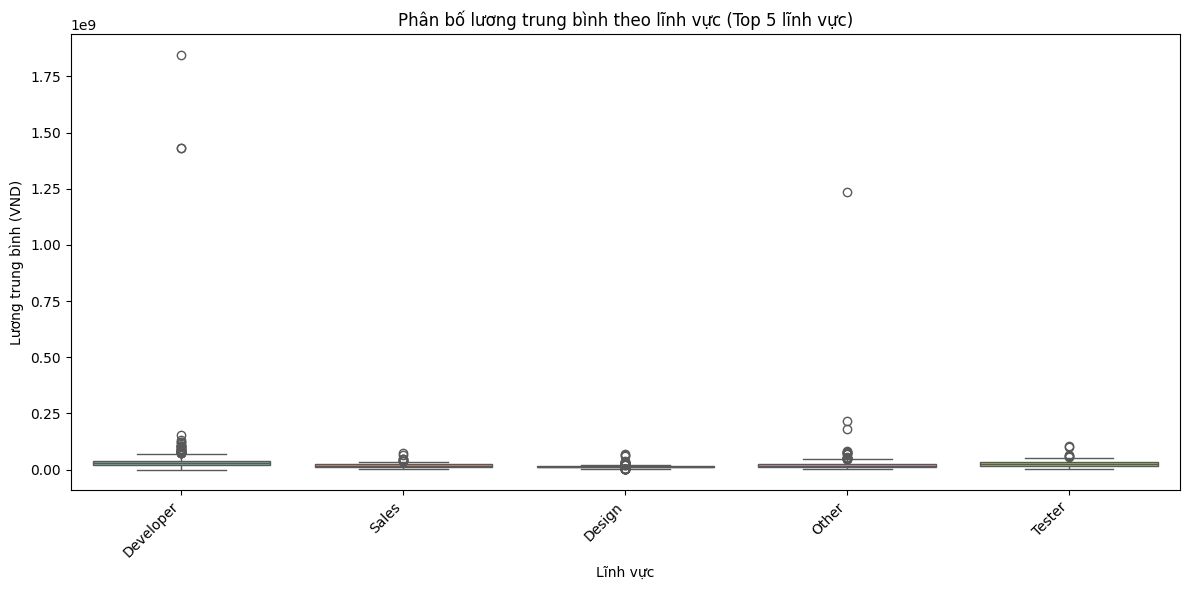

In [3]:
top_fields_salary = df_salary_valid['job_field'].value_counts().head(5).index
df_top_fields_salary = df_salary_valid[df_salary_valid['job_field'].isin(top_fields_salary)]

plt.figure(figsize=(12,6))
sns.boxplot(data=df_top_fields_salary, x='job_field', y='avg_salary', palette='Set2')
plt.title('Phân bố lương trung bình theo lĩnh vực (Top 5 lĩnh vực)')
plt.xlabel('Lĩnh vực')
plt.ylabel('Lương trung bình (VND)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

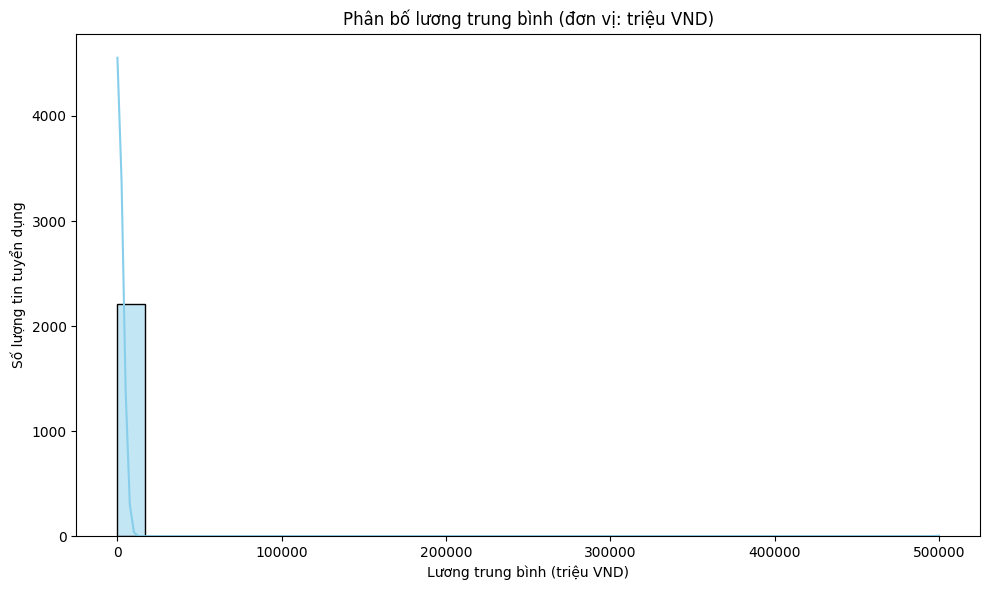

In [4]:
# 3. Biểu đồ phân bố (histogram) của avg_salary
plt.figure(figsize=(10,6))
sns.histplot(df_salary_valid['avg_salary'] / 1e6, bins=30, kde=True, color='skyblue')
plt.title('Phân bố lương trung bình (đơn vị: triệu VND)')
plt.xlabel('Lương trung bình (triệu VND)')
plt.ylabel('Số lượng tin tuyển dụng')
plt.tight_layout()
plt.show()
